In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("cleaned_dataset.csv")

print("Original Dataset Shape:", df.shape)

Original Dataset Shape: (10, 6)


In [ ]:
import pandas as pd
import numpy as np

# Create a sample DataFrame with various data types, missing values, and duplicates
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1, 2],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy', 'Alice', 'Bob'],
    'Age': [24, 30, np.nan, 28, 35, 40, 22, np.nan, 31, 29, 24, 30],
    'City': ['New York', 'London', 'Paris', 'Tokyo', 'Berlin', 'Rome', 'Madrid', 'London', 'Paris', 'New York', 'New York', 'London'],
    'Score': [85.5, 78.0, 92.1, 70.3, np.nan, 88.9, 95.0, 65.2, 81.7, 74.4, 85.5, 78.0],
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10', '2023-01-01', '2023-01-02']
}
df_sample = pd.DataFrame(data)

# Save the sample DataFrame to a CSV file named 'dataset.csv'
df_sample.to_csv('dataset.csv', index=False)

print("Sample 'dataset.csv' created successfully with dummy data.")
print("You can now run the subsequent data cleaning cells.")

Sample 'dataset.csv' created successfully with dummy data.
You can now run the subsequent data cleaning cells.


**1. Check Missing Values**

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill text missing values with mode
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


Missing Values:
ID       0
Name     0
Age      0
City     0
Score    0
Date     0
dtype: int64


/tmp/ipykernel_34735/3519850543.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_34735/3519850543.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

**2. Remove Duplicates**

In [ ]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")

df = df.drop_duplicates()



Duplicate Rows Found: 0


**3. Standardize Text Columns**

In [ ]:
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

**4. Correct Date Formats**

In [ ]:
date_columns = ['Date']  # Replace with actual date column name

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"{col} formatted successfully")

Date formatted successfully


**5. Check Remaining Missing Values**

In [ ]:
print("\nRemaining Missing Values:")
print(df.isnull().sum())


Remaining Missing Values:
ID       0
Name     0
Age      0
City     0
Score    0
Date     0
dtype: int64


**6. Save Cleaned Dataset**

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

print("\nData Cleaning Completed Successfully!")
print("Cleaned file saved as: cleaned_dataset.csv")
print("Final Dataset Shape:", df.shape)


Data Cleaning Completed Successfully!
Cleaned file saved as: cleaned_dataset.csv
Final Dataset Shape: (10, 6)


### Upload Cleaned Dataset to Google Drive

To upload the `cleaned_dataset.csv` file to your Google Drive, we first need to mount your Drive. Then, we will copy the file to a specified location in your Drive.

In [ ]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define source and destination paths
source_path = 'cleaned_dataset.csv'
destination_folder = '/content/drive/MyDrive/Colab Notebooks/' # You can change this to any folder in your Drive

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy the file to Google Drive
shutil.copy(source_path, destination_folder)

print(f"'{source_path}' successfully uploaded to '{destination_folder}'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'cleaned_dataset.csv' successfully uploaded to '/content/drive/MyDrive/Colab Notebooks/'


The `cleaned_dataset.csv` file has been uploaded to your Google Drive in the `Colab Notebooks` folder (or the folder you specified). You can now go to your Google Drive, locate the file, right-click on it, select 'Share', and then 'Get link' to obtain a shareable URL.

### Visualization of 'Score' Column

Let's visualize the distribution of the 'Score' column using a histogram.

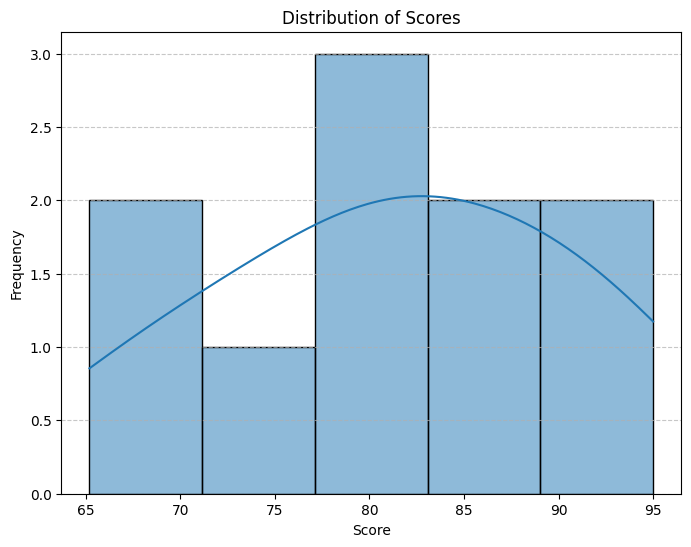

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['Score'], kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Summary Statistics for 'Score' Column

Let's calculate the descriptive statistics for the 'Score' column.

In [ ]:
print(df['Score'].describe())

count    10.000000
mean     81.280000
std       9.537971
min      65.200000
25%      75.300000
50%      81.700000
75%      88.050000
max      95.000000
Name: Score, dtype: float64


### Exploring 'Score' by 'City'

Let's visualize the average 'Score' for each 'City' to identify any regional differences.

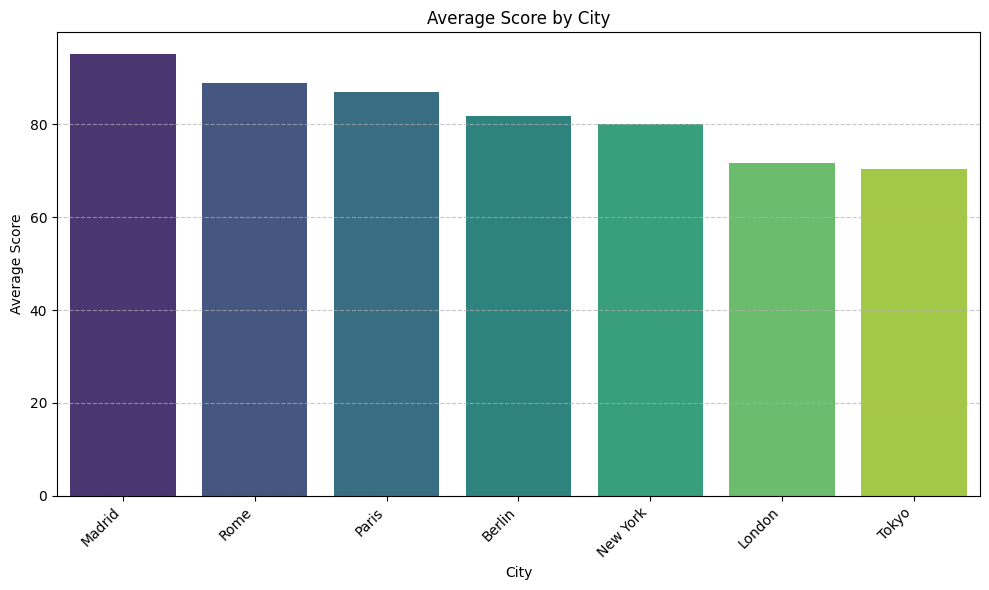

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average score per city
avg_score_by_city = df.groupby('City')['Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='City', y='Score', data=avg_score_by_city, hue='City', palette='viridis', legend=False)
plt.title('Average Score by City')
plt.xlabel('City')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exploring 'Score' by 'Age'

Let's visualize the relationship between 'Score' and 'Age' using a scatter plot to identify any potential correlations.

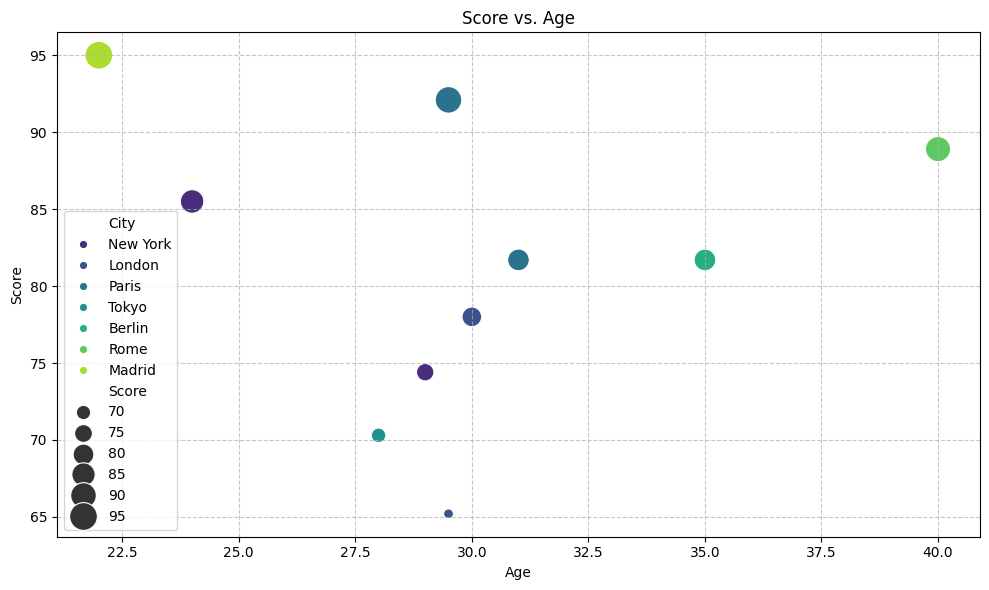

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Score', data=df, hue='City', size='Score', sizes=(50, 400), palette='viridis')
plt.title('Score vs. Age')
plt.xlabel('Age')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
pip install streamlit ngrok pyngrok matplotlib seaborn

Now, let's create a Streamlit application file (`app.py`). This file will contain the code for your web app. For this example, we'll make it display the `cleaned_dataset.csv`.

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import os

st.set_page_config(layout="wide")

st.title('Data Cleaning & EDA Web App')
st.write('This is an interactive web application to showcase the cleaned dataset and its exploratory data analysis.')

# Load the cleaned data
@st.cache_data
def load_data():
    # Use the absolute path where cleaned_dataset.csv is consistently saved in Colab
    file_path = '/content/cleaned_dataset.csv' # Explicitly set to absolute path
    data = pd.read_csv(file_path)
    return data

df_cleaned = load_data()

st.header('Cleaned Dataset')
st.dataframe(df_cleaned)

st.header('Summary Statistics for Score')
st.write(df_cleaned['Score'].describe())

# You can add more visualizations here from your EDA steps
# For example, a histogram of the 'Score' column:
import matplotlib.pyplot as plt
import seaborn as sns

st.header('Distribution of Scores')
fig_hist, ax_hist = plt.subplots(figsize=(10, 6))
sns.histplot(df_cleaned['Score'], kde=True, ax=ax_hist)
ax_hist.set_title('Distribution of Scores')
ax_hist.set_xlabel('Score')
ax_hist.set_ylabel('Frequency')
st.pyplot(fig_hist)


# You can also add the Average Score by City Bar Plot
st.header('Average Score by City')
avg_score_by_city = df_cleaned.groupby('City')['Score'].mean().sort_values(ascending=False).reset_index()
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
sns.barplot(x='City', y='Score', data=avg_score_by_city, hue='City', palette='viridis', legend=False, ax=ax_bar)
ax_bar.set_title('Average Score by City')
ax_bar.set_xlabel('City')
ax_bar.set_ylabel('Average Score')
ax_bar.tick_params(axis='x', rotation=45)
st.pyplot(fig_bar)

Overwriting app.py


Finally, we'll run the Streamlit app. Since Streamlit runs on a local server, we'll use `ngrok` to expose it to the internet, giving you a public URL (your 'live link').

In [ ]:
from pyngrok import ngrok

# Terminate ngrok tunnels if any are already running
ngrok.kill()

# Authenticate ngrok (you'll need an ngrok auth token - get one from ngrok.com)
# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual token
# If you don't have one, you can skip this, but ngrok might limit access.
ngrok.set_auth_token("3CFZWRhgtm4RKxBtezQTxwrYmZW_4umT9DkH4khjsi96VZnMr") # <--- **UNCOMMENT THIS LINE AND REPLACE WITH YOUR TOKEN**

# Start a ngrok tunnel to the Streamlit port (default is 8501)
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run the Streamlit app
!streamlit run app.py &>/dev/null

Streamlit App URL: NgrokTunnel: "https://dangling-reproach-salami.ngrok-free.dev" -> "http://localhost:8501"


After running the cell above, you will see a 'Streamlit App URL:' printed in the output. Click on that link to access your live Streamlit web application. It might take a few moments for the app to load in the browser.